In [5]:
import math
import scipy
import numpy as np
import matplotlib.pyplot as plt

In [6]:
def F(t,y):
  return -y + 2*math.sin(t)

def analytical_solution(t):
    return 2*math.exp(-t) + math.sqrt(2) * math.sin(t - math.atan(0.5))


# Начальное условие
y0 = 1
# Интервал решения
tmax = 5
# Шаг решения
h = 0.1
# Создаём числовую последовательность значений t
t = np.arange(0,tmax+h,h)
# Определяем общее число шагов решения
N = len(t)
# Заполняем массив y нулями
y = np.zeros(N)
# Первой ячейке массива y присваиваем начальное условие
y[0] = y0
# Задаем точность решения уравнения на каждом шаге интегрирования
e = 0.0001

# Неявный метод Эйлера
for k in range(0, N):
    z = 1
    while abs(z-y[k]) > e:
        y[k] = z
        z = y[k-1] + h*F(t[k], z)

# Расчет аналитического решения
t2 = np.arange(0,tmax+h,h)
y2 = np.zeros(N)
for k in range(0, N):
    y2[k] = analytical_solution(t2[k])

In [7]:
solve_ivp_solution = scipy.integrate.solve_ivp(F,[0,tmax],[y0],method='RK45',max_step=h)
solve_ivp_solution

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  8.029e-02 ...  4.980e+00  5.000e+00]
        y: [[ 1.000e+00  9.291e-01 ... -1.215e+00 -1.229e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 308
     njev: 0
      nlu: 0

NameError: name 't3' is not defined

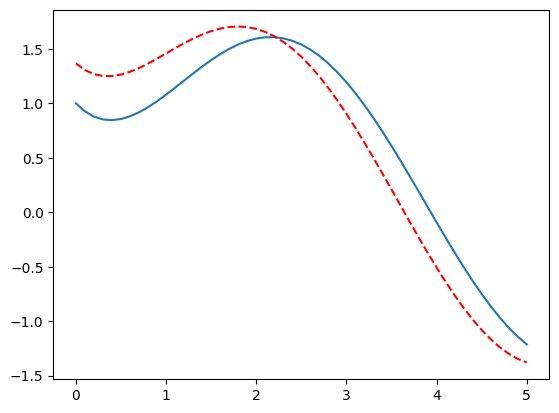

In [8]:
# Строим графики решений
plt.figure(1)
plt.plot(t,y,label='Численное решение')
plt.plot(t2,y2,'r--',label='Аналитическое решение')
plt.plot(t3,y3,'g-.',label='Решение при помощи solve_ivp')
plt.legend()
plt.grid()

Text(0.5, 1.0, 'График тока в катушке')

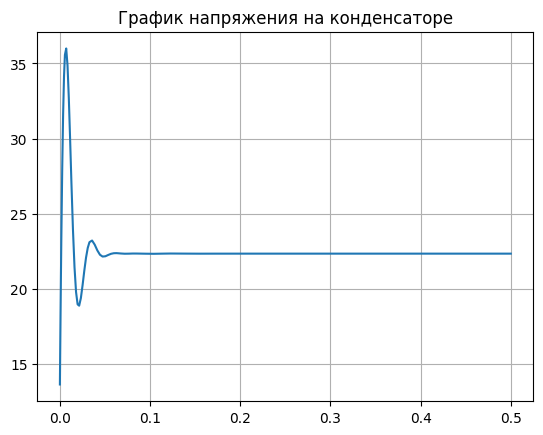

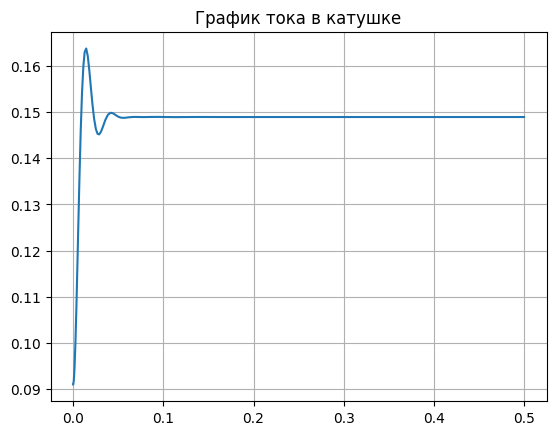

In [9]:
# Расчёт переходного процесса в RLC-контуре
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Параметры схемы
R1 = 50
R2 = 1500
R3 = 100
R4 = 2000
L = 2
C = 10E-6
E = 150

# Функция с правыми частями системы уравнений
def fun1(t,y):
  
  global R1,R2,R3,R4,L,C,E
  # Вводим обозначения неизвестных, вместо y0, y1
  uc = y[0]
  i = y[1]
  # Рассчитываем и возвращаем производные

  R_e = R2*R4 / (R2 + R4)

  duc = (((E - uc) / R_e) - i) / C
  di = (uc - i*(R1 + R3)) / L
  return [duc, di]

# Задаем время решения
tmax = 0.5

# Задаем начальные условия
uc0 = 13.63
i0 = 0.091

# Вызываем решатель

sol = solve_ivp(fun1,[0,tmax],[uc0,i0],method = 'BDF')

t = sol.t
uc = sol.y[0,:]
i = sol.y[1,:]

# Строим графики решения
plt.figure(1)
plt.plot(t,uc)
plt.grid()
plt.title('График напряжения на конденсаторе')

plt.figure(2)
plt.plot(t,i)
plt.grid()
plt.title('График тока в катушке')